dataset of comments from Wikipedia’s talk page edits

https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge/overview

You are provided with a large number of Wikipedia comments which have been labeled by human raters for toxic behavior. The types of toxicity are:

toxic
severe_toxic
obscene
threat
insult
identity_hate


#### 0. importar los datos

In [ ]:
import pandas as pd

# Load zipped CSVs directly
train = pd.read_csv('train.csv.zip')
test = pd.read_csv('test.csv.zip') 

FileNotFoundError: [Errno 2] No such file or directory: 'test.csv.zip'

In [ ]:
train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


#### 1. Construccion de features

Construimos variables que creemos que puede tener relevancia

Ideas:
- longitud
- num palabras
- presencia de #
- presencia de emojies
- contar: adjetivos, nombre, verbos, ...
- contar nombres propios
- malas palabras
- ...



#### 1.1 Contar palabras y longitud del texto

In [ ]:
train['comment_length'] = train['comment_text'].apply(len)
train['word_count'] = train['comment_text'].apply(lambda x: len(x.split()))

#### 1.2 Presencia de caracteres especiales: emojies, hashtags

In [ ]:
import re
# Expresión regular para detectar emojis
emoji_pattern = re.compile("[\U0001F600-\U0001F64F"  # emoticons
                           "\U0001F300-\U0001F5FF"  # symbols & pictographs
                           "\U0001F680-\U0001F6FF"  # transport & map symbols
                           "\U0001F1E0-\U0001F1FF"  # flags
                           "\U00002700-\U000027BF"  # dingbats
                           "\U0001F900-\U0001F9FF"  # supplemental symbols
                           "\U00002600-\U000026FF"  # miscellaneous symbols
                           "]+", flags=re.UNICODE)

# Crear variable binaria
train['has_emoji'] = train['comment_text'].apply(lambda x: 1 if emoji_pattern.search(x) else 0)

print(train)

                      id                                       comment_text  \
0       0000997932d777bf  Explanation\nWhy the edits made under my usern...   
1       000103f0d9cfb60f  D'aww! He matches this background colour I'm s...   
2       000113f07ec002fd  Hey man, I'm really not trying to edit war. It...   
3       0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...   
4       0001d958c54c6e35  You, sir, are my hero. Any chance you remember...   
...                  ...                                                ...   
159566  ffe987279560d7ff  ":::::And for the second time of asking, when ...   
159567  ffea4adeee384e90  You should be ashamed of yourself \n\nThat is ...   
159568  ffee36eab5c267c9  Spitzer \n\nUmm, theres no actual article for ...   
159569  fff125370e4aaaf3  And it looks like it was actually you who put ...   
159570  fff46fc426af1f9a  "\nAnd ... I really don't think you understand...   

        toxic  severe_toxic  obscene  threat  insul

In [ ]:
# Detecta cualquier palabra que empiece con # seguida de letras, números o guiones bajos.

hashtag_pattern = re.compile(r"#\w+")

train['has_hash'] = train['comment_text'].apply(lambda x: 1 if hashtag_pattern.search(x) else 0)
train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,word_count,has_emoji,has_hash
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,43,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,17,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,42,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,113,0,1
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,13,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,295,47,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,99,18,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,81,12,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,116,25,0,0


Identificamos en los comentarios los adjetivos, nombre y verbos empleados

#### 1.3 Adjetivos, nombre

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')




# Función para contar POS
def count_pos(text):
    tokens = nltk.word_tokenize(text)
    tagged = nltk.pos_tag(tokens)

    # POS tags: https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html
    adj = sum(1 for word, tag in tagged if tag.startswith('JJ'))   # Adjectives
    noun = sum(1 for word, tag in tagged if tag.startswith('NN'))  # Nouns
    verb = sum(1 for word, tag in tagged if tag.startswith('VB'))  # Verbs
    return pd.Series([adj, noun, verb])

# Aplicar al DataFrame
# Recursos adicionales requeridos por versiones recientes de NLTK
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Aplicar al DataFrame (evita fallos si hubiera nulos)
train[['num_adj', 'num_noun', 'num_verb']] = (
    train['comment_text'].fillna('').apply(count_pos)
)

print(train)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


                      id                                       comment_text  \
0       0000997932d777bf  Explanation\nWhy the edits made under my usern...   
1       000103f0d9cfb60f  D'aww! He matches this background colour I'm s...   
2       000113f07ec002fd  Hey man, I'm really not trying to edit war. It...   
3       0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...   
4       0001d958c54c6e35  You, sir, are my hero. Any chance you remember...   
...                  ...                                                ...   
159566  ffe987279560d7ff  ":::::And for the second time of asking, when ...   
159567  ffea4adeee384e90  You should be ashamed of yourself \n\nThat is ...   
159568  ffee36eab5c267c9  Spitzer \n\nUmm, theres no actual article for ...   
159569  fff125370e4aaaf3  And it looks like it was actually you who put ...   
159570  fff46fc426af1f9a  "\nAnd ... I really don't think you understand...   

        toxic  severe_toxic  obscene  threat  insul

In [ ]:
train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,word_count,has_emoji,has_hash,num_adj,num_noun,num_verb
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,43,0,0,3,15,9
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,17,0,0,0,6,3
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,42,0,0,2,10,9
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,113,0,1,7,26,24
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,13,0,0,0,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,295,47,0,0,5,8,9
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,99,18,0,0,1,3,4
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,81,12,0,0,1,7,1
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,116,25,0,0,1,2,6


#### 1.4 Malas palabras

LDNOOBW   
https://github.com/LDNOOBW/List-of-Dirty-Naughty-Obscene-and-Otherwise-Bad-Words/blob/master/en

In [ ]:
def cargar_LDNOOBW(path="LDNOOBW.txt"):
    with open(path, "r", encoding="utf-8") as f:
        palabras = set(
            line.strip().lower()
            for line in f
            if line.strip()
        )
    return palabras

diccionario_ldnoobw = cargar_LDNOOBW()
print(f"Diccionario cargado con {len(diccionario_ldnoobw)} palabras ofensivas.")


Diccionario cargado con 403 palabras ofensivas.


In [ ]:
diccionario_ldnoobw

{'2 girls 1 cup',
 '2g1c',
 'acrotomophilia',
 'alabama hot pocket',
 'alaskan pipeline',
 'anal',
 'anilingus',
 'anus',
 'apeshit',
 'arsehole',
 'ass',
 'asshole',
 'assmunch',
 'auto erotic',
 'autoerotic',
 'babeland',
 'baby batter',
 'baby juice',
 'ball gag',
 'ball gravy',
 'ball kicking',
 'ball licking',
 'ball sack',
 'ball sucking',
 'bangbros',
 'bangbus',
 'bareback',
 'barely legal',
 'barenaked',
 'bastard',
 'bastardo',
 'bastinado',
 'bbw',
 'bdsm',
 'beaner',
 'beaners',
 'beastiality',
 'beaver cleaver',
 'beaver lips',
 'bestiality',
 'big black',
 'big breasts',
 'big knockers',
 'big tits',
 'bimbos',
 'birdlock',
 'bitch',
 'bitches',
 'black cock',
 'blonde action',
 'blonde on blonde action',
 'blow job',
 'blow your load',
 'blowjob',
 'blue waffle',
 'blumpkin',
 'bollocks',
 'bondage',
 'boner',
 'boob',
 'boobs',
 'booty call',
 'brown showers',
 'brunette action',
 'bukkake',
 'bulldyke',
 'bullet vibe',
 'bullshit',
 'bung hole',
 'bunghole',
 'busty',


In [ ]:
import re

def detectar_ofensivo_LDNOOBW(texto, diccionario):
    if not isinstance(texto, str):
        return 0  # por si hay NaNs

    texto_proc = texto.lower()

    # Tokenización básica
    palabras = re.findall(r"[a-zA-Z0-9]+", texto_proc)

    for palabra in palabras:
        # 1. Coincidencia exacta
        if palabra in diccionario:
            return 1
        
        # 2. Coincidencia por elongación (ej: stupiiiid → stupid)
        palabra_sin_rep = re.sub(r"(.)\1+", r"\1", palabra)
        if palabra_sin_rep in diccionario:
            return 1
        
        # 3. Coincidencia con números (leetspeak)
        palabra_leet = (
            palabra.replace("0", "o")
                   .replace("1", "i")
                   .replace("3", "e")
                   .replace("4", "a")
                   .replace("5", "s")
                   .replace("7", "t")
        )
        if palabra_leet in diccionario:
            return 1

    return 0


In [ ]:
train["has_badword"] = train["comment_text"].apply(
    lambda x: detectar_ofensivo_LDNOOBW(x, diccionario_ldnoobw)
)

train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,word_count,has_emoji,has_hash,num_adj,num_noun,num_verb,has_badword
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,43,0,0,3,15,9,1
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,17,0,0,0,6,3,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,42,0,0,2,10,9,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,113,0,1,7,26,24,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,13,0,0,0,3,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,295,47,0,0,5,8,9,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,99,18,0,0,1,3,4,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,81,12,0,0,1,7,1,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,116,25,0,0,1,2,6,0


In [ ]:
def contar_ofensivas(texto, diccionario):
    if not isinstance(texto, str):
        return 0

    texto_proc = texto.lower()
    palabras = re.findall(r"[a-zA-Z0-9]+", texto_proc)

    count = 0
    for palabra in palabras:
        if palabra in diccionario:
            count += 1
    return count

train["num_badwords"] = train["comment_text"].apply(
    lambda x: contar_ofensivas(x, diccionario_ldnoobw)
)

test["num_badwords"] = test["comment_text"].apply(
    lambda x: contar_ofensivas(x, diccionario_ldnoobw)
)

In [ ]:
train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,word_count,has_emoji,has_hash,num_adj,num_noun,num_verb,has_badword,num_badwords
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,43,0,0,3,15,9,1,1
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,17,0,0,0,6,3,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,42,0,0,2,10,9,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,113,0,1,7,26,24,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,13,0,0,0,3,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,295,47,0,0,5,8,9,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,99,18,0,0,1,3,4,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,81,12,0,0,1,7,1,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,116,25,0,0,1,2,6,0,0


#### 1.6 Construyo ratios

In [ ]:
train['ratio_adj']=train['num_adj']/train['word_count']
train['ratio_noun']=train['num_noun']/train['word_count']
train['ratio_verb']=train['num_verb']/train['word_count']
train['ratio_bad']=train['num_badwords']/train['word_count']


train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,word_count,...,has_hash,num_adj,num_noun,num_verb,has_badword,num_badwords,ratio_adj,ratio_noun,ratio_verb,ratio_bad
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,43,...,0,3,15,9,1,1,0.069767,0.348837,0.209302,0.023256
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,17,...,0,0,6,3,0,0,0.000000,0.352941,0.176471,0.000000
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,42,...,0,2,10,9,0,0,0.047619,0.238095,0.214286,0.000000
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,113,...,1,7,26,24,0,0,0.061947,0.230088,0.212389,0.000000
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,13,...,0,0,3,4,0,0,0.000000,0.230769,0.307692,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,295,47,...,0,5,8,9,0,0,0.106383,0.170213,0.191489,0.000000
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,99,18,...,0,1,3,4,0,0,0.055556,0.166667,0.222222,0.000000
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,81,12,...,0,1,7,1,0,0,0.083333,0.583333,0.083333,0.000000
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,116,25,...,0,1,2,6,0,0,0.040000,0.080000,0.240000,0.000000


#### 2. EDA

analizamos las variables numericas

In [ ]:
def tipo_variables(df):
    dtypes = df.dtypes
    categorical_cols = []
    numerical_cols = []
    for col, dtype in dtypes.items():
        if pd.api.types.is_numeric_dtype(dtype):
            numerical_cols.append(col)
        else:
            categorical_cols.append(col)
    return numerical_cols, categorical_cols
    
vbles = tipo_variables(train)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['id', 'comment_text']
['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'comment_length', 'word_count', 'has_emoji', 'has_hash', 'num_adj', 'num_noun', 'num_verb', 'has_badword', 'num_badwords', 'ratio_adj', 'ratio_noun', 'ratio_verb', 'ratio_bad']


In [ ]:
import math
import scipy.stats as stats
import matplotlib.pyplot as plt
# Seaborn is a Python data visualization library based on matplotlib
import seaborn as sns
%matplotlib inline

In [ ]:
def plot_numerical(df):
    numerical_cols=tipo_variables(df)[0]
    a= math.floor(math.sqrt(len(numerical_cols)))+1
    fig, axes = plt.subplots(a, a, figsize=(25,25))
    axes = axes.flatten()
    i = 0
    for t in numerical_cols:
        ax = sns.histplot(data=df, x=t, bins=20,  ax=axes[i])
        i +=1
    plt.show()

def plot_numericalBox(df):
    import math
    import scipy.stats as stats
    
    #a= math.floor(math.sqrt(len(num_vbles)))+1
    num_vbles=tipo_variables(df)[0]
    fig, axes = plt.subplots(math.floor(len(num_vbles)/3)+1,3, figsize=(25,25))
    axes = axes.flatten()
    i = 0
    for i, t in enumerate(num_vbles):
        transformed_data, _ = stats.boxcox(df[t] + 1)  # Se suma 1 para evitar valores negativos/cero
        sns.boxplot(y=transformed_data, ax=axes[i])  # Boxplot en orientación vertical
        axes[i].set_title(f"Box-Cox de {t}")
    plt.tight_layout()
    plt.show()

def plot_categorial(df):
    categorical_cols=tipo_variables(df)[1]
    a= math.floor(math.sqrt(len(categorical_cols)))+1
    #fig, axes = plt.subplots(a, a, figsize=(25,25))
    fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(20,160))
    axes = axes.flatten()
    i = 0
    for t in categorical_cols:
        ax = sns.countplot(x=t, data=df, ax=axes[i])
        i +=1
    plt.show()    

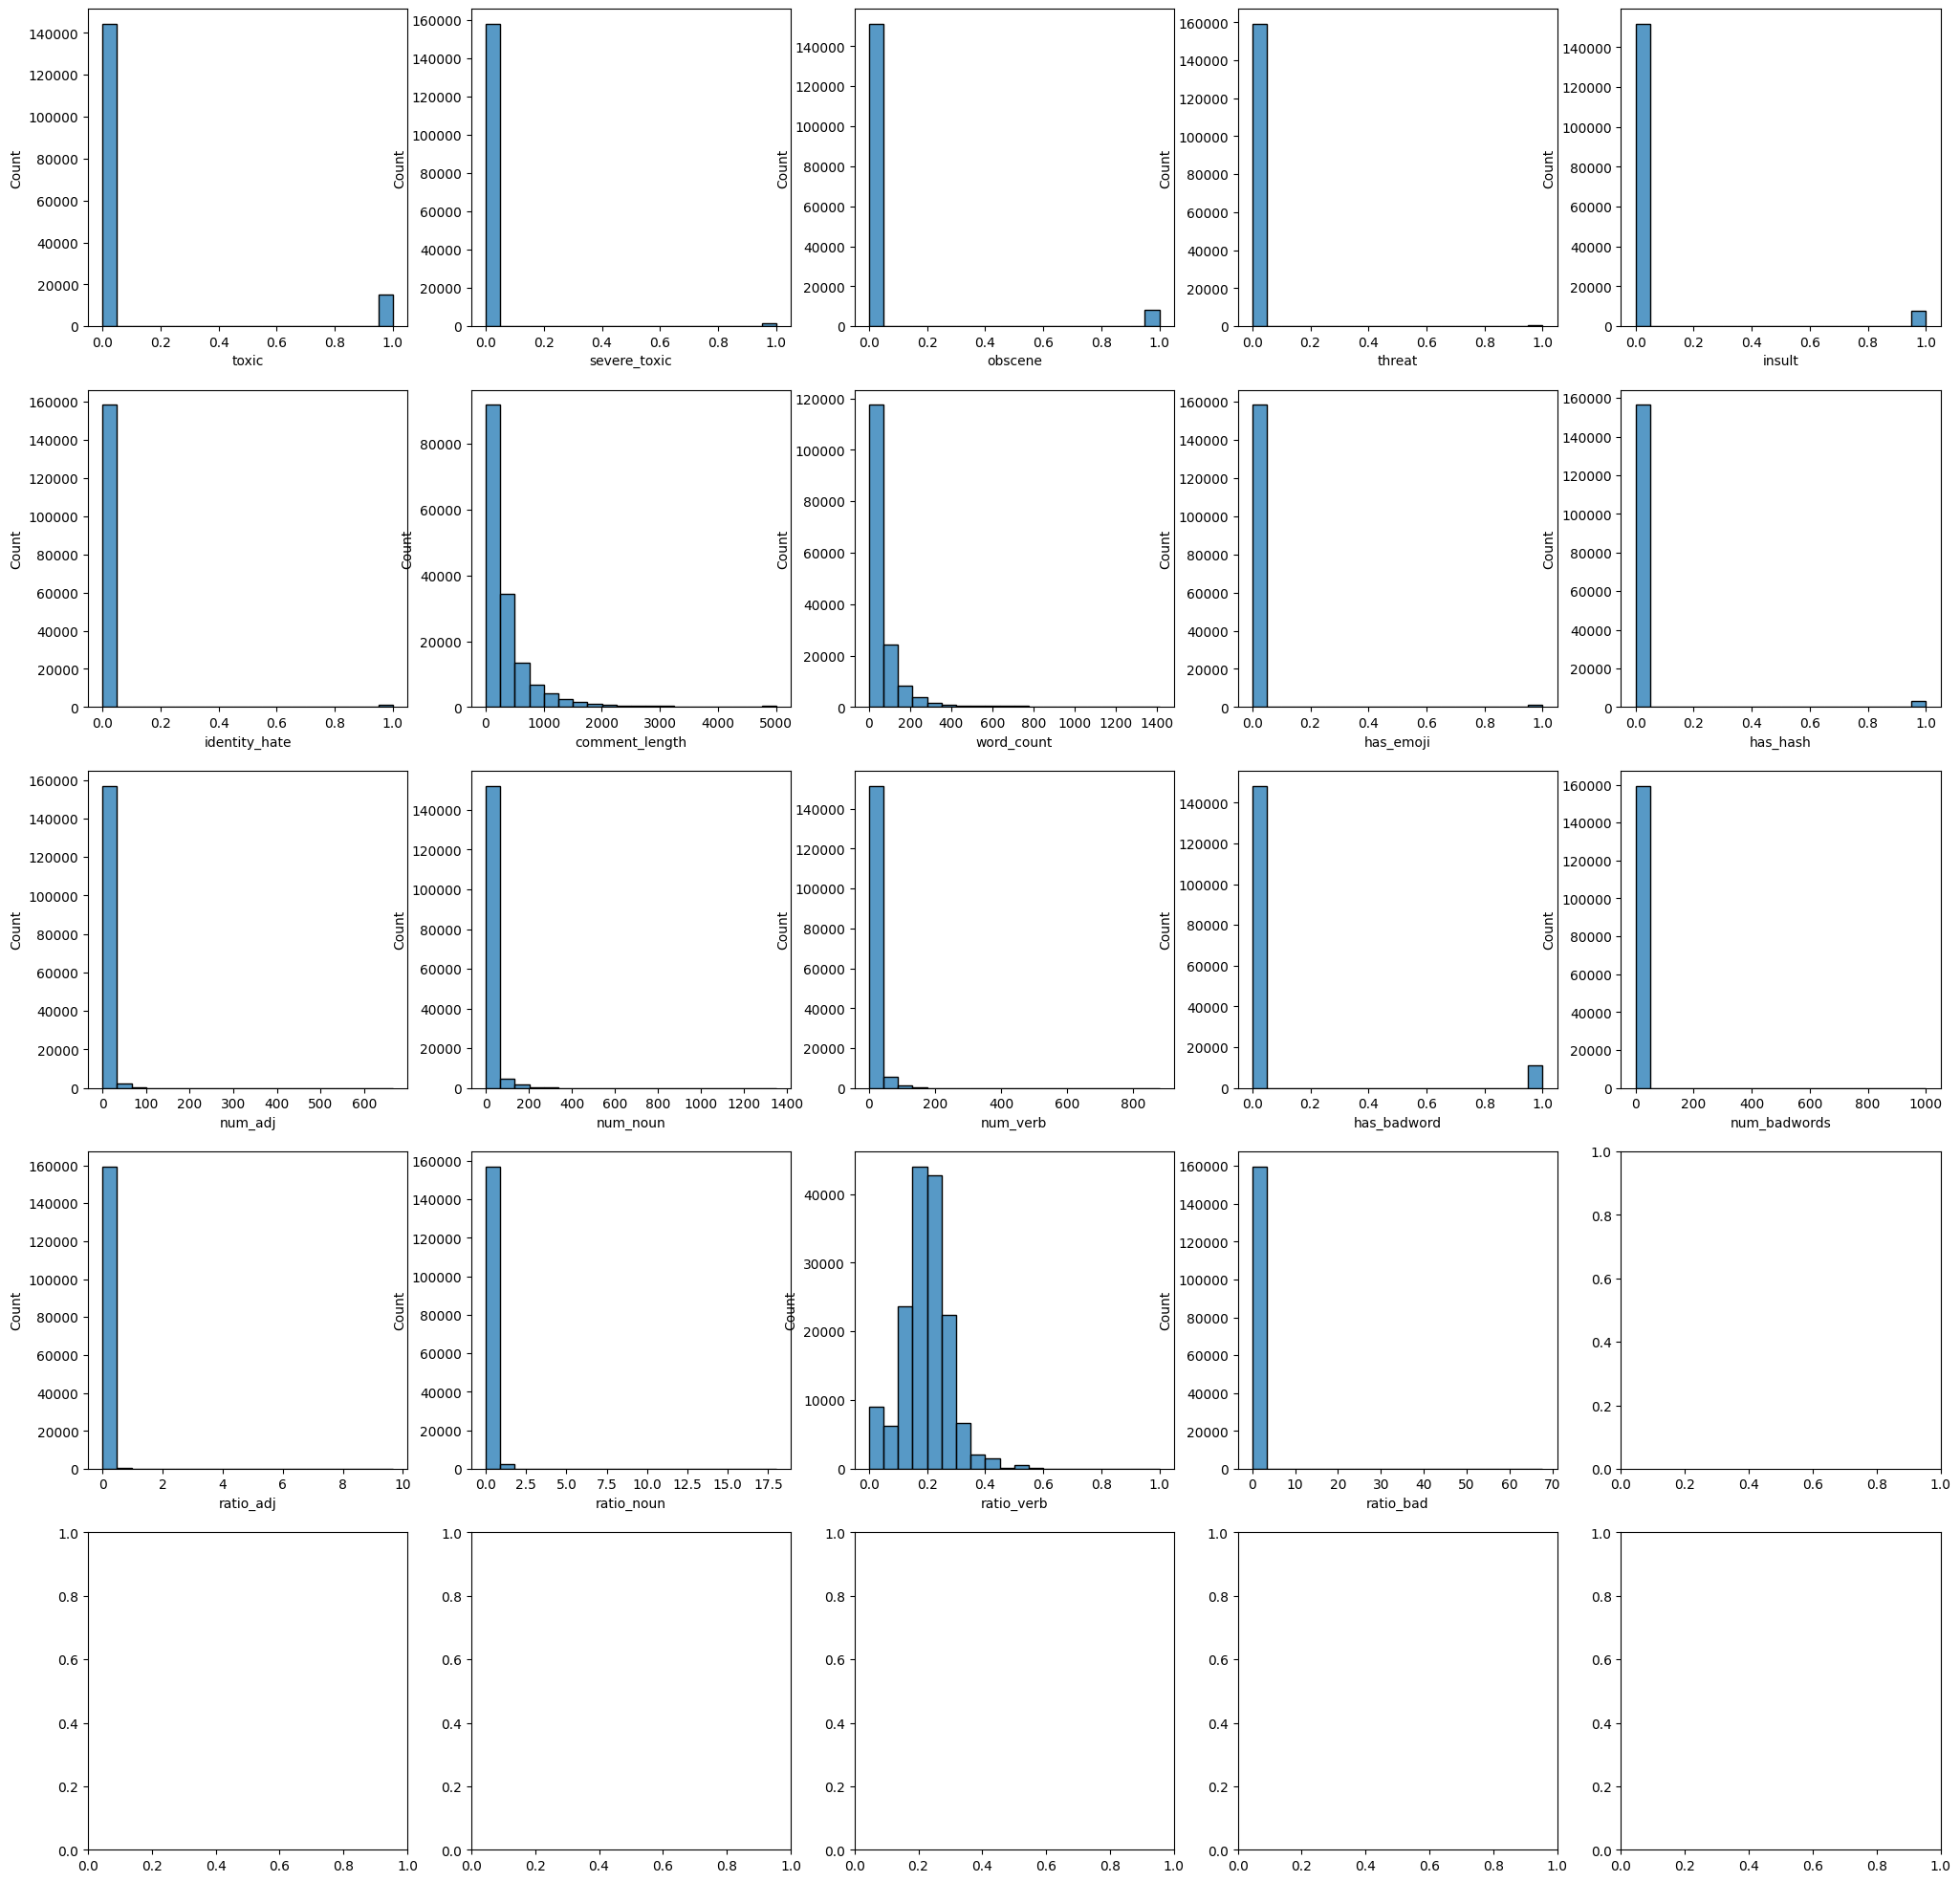

In [ ]:
plot_numerical(train)

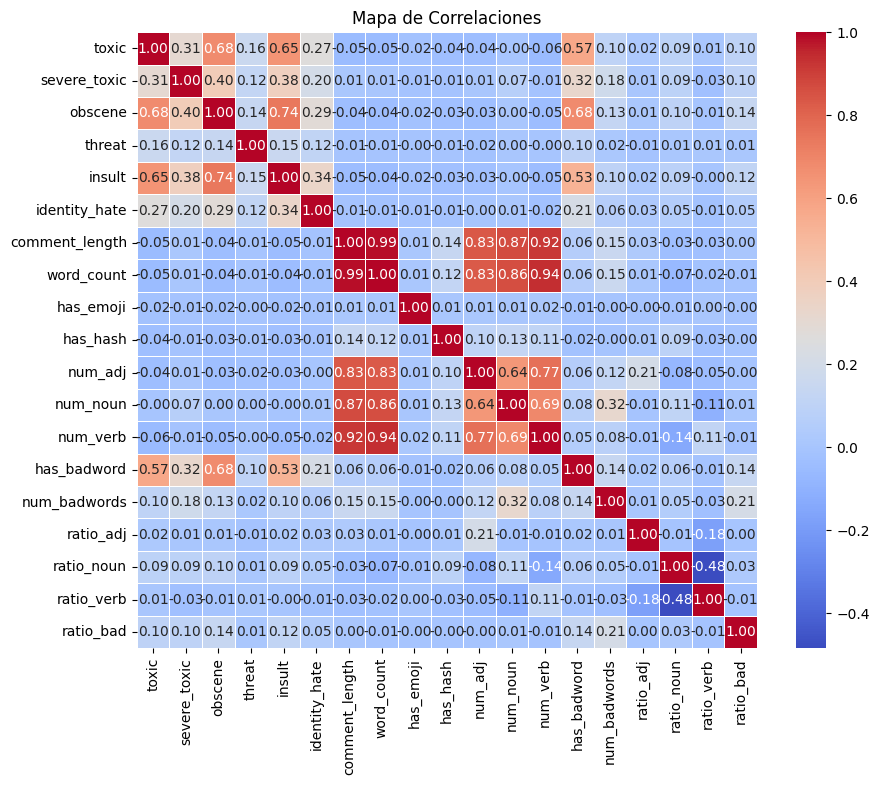

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular matriz de correlación
corr_matrix = train[num_vbles].corr()

#  Generar el heatmap de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlaciones")
plt.show()

#### 3.Transformamos nuestro texto en un embedding 

#### 3.1 limpieza

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

def limpiar_texto(texto):
    texto = texto.replace("\n", " ")  # Eliminar saltos de línea
    texto = texto.lower()  # Convertir a minúsculas
    texto = re.sub(r'[^\w\s]', '', texto)  # Eliminar signos de puntuación
    stop_words = set(stopwords.words('english'))
    texto = " ".join(word for word in texto.split() if word not in stop_words)  # Eliminar stopwords
    return texto

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
train['comments_clean']= [limpiar_texto(comment) for comment in train['comment_text']]
train['comments_clean']   

0         explanation edits made username hardcore metal...
1         daww matches background colour im seemingly st...
2         hey man im really trying edit war guy constant...
3         cant make real suggestions improvement wondere...
4                       sir hero chance remember page thats
                                ...                        
159566    second time asking view completely contradicts...
159567       ashamed horrible thing put talk page 128611993
159568    spitzer umm theres actual article prostitution...
159569    looks like actually put speedy first version d...
159570    really dont think understand came idea bad rig...
Name: comments_clean, Length: 159571, dtype: str

#### 3.2 Tokenizado

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

# Entrenar el tokenizer con todo el corpus
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(train['comments_clean'])

# Obtener listas de palabras (no matrices)
tokenized_comments = tokenizer.texts_to_sequences(train['comments_clean'])

# Convertir índices a palabras (opcional)
word_index = tokenizer.word_index
index_word = {v: k for k, v in word_index.items()}

# Reconstruir comentarios como listas de palabras
tokenized_words = [[index_word.get(i, '') for i in seq] for seq in tokenized_comments]

In [ ]:
train['comments_clean_t']= tokenized_comments
train['comments_clean_t']

0         [529, 44, 47, 521, 4454, 1143, 208, 1924, 6438...
1         [2358, 1298, 3531, 13, 4140, 2440, 21, 4, 809,...
2         [314, 328, 13, 50, 141, 16, 212, 472, 2024, 35...
3         [102, 24, 220, 1275, 1879, 5485, 43, 2284, 376...
4                             [1519, 3290, 868, 432, 2, 82]
                                ...                        
159566    [301, 20, 714, 205, 412, 5341, 1396, 160, 30, ...
159567                         [4213, 3012, 130, 101, 4, 2]
159568                [7304, 269, 559, 1, 7700, 3328, 4327]
159569             [420, 8, 108, 101, 146, 35, 265, 55, 62]
159570    [50, 9, 12, 144, 435, 284, 231, 60, 367, 310, ...
Name: comments_clean_t, Length: 159571, dtype: object

#### 3.3 Embedding

In [ ]:
from gensim.models import Word2Vec

# Entrenar Word2Vec con tus comentarios tokenizados
w2v_model = Word2Vec(sentences=tokenized_words, vector_size=100, window=5, min_count=5, workers=4)


In [ ]:
import numpy as np

def get_comment_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# Aplicar al dataset
train['comment_vector'] = [get_comment_vector(tokens, w2v_model) for tokens in tokenized_words]


In [ ]:
train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length,word_count,...,num_verb,has_badword,num_badwords,ratio_adj,ratio_noun,ratio_verb,ratio_bad,comments_clean,comments_clean_t,comment_vector
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264,43,...,9,1,1,0.069767,0.348837,0.209302,0.023256,explanation edits made username hardcore metal...,"[529, 44, 47, 521, 4454, 1143, 208, 1924, 6438...","[-0.11725688, -0.21249305, 0.05359391, 0.32341..."
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112,17,...,3,0,0,0.000000,0.352941,0.176471,0.000000,daww matches background colour im seemingly st...,"[2358, 1298, 3531, 13, 4140, 2440, 21, 4, 809,...","[0.3572333, -0.0205397, 0.5587838, 0.12707984,..."
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233,42,...,9,0,0,0.047619,0.238095,0.214286,0.000000,hey man im really trying edit war guy constant...,"[314, 328, 13, 50, 141, 16, 212, 472, 2024, 35...","[0.19481017, -0.5335389, 0.1807041, 0.28031895..."
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622,113,...,24,0,0,0.061947,0.230088,0.212389,0.000000,cant make real suggestions improvement wondere...,"[102, 24, 220, 1275, 1879, 5485, 43, 2284, 376...","[0.7542522, -0.675318, -0.06765947, 0.4821063,..."
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67,13,...,4,0,0,0.000000,0.230769,0.307692,0.000000,sir hero chance remember page thats,"[1519, 3290, 868, 432, 2, 82]","[-0.85153526, -0.4269875, -0.2262776, 0.733056..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,295,47,...,9,0,0,0.106383,0.170213,0.191489,0.000000,second time asking view completely contradicts...,"[301, 20, 714, 205, 412, 5341, 1396, 160, 30, ...","[0.62088317, -0.4908837, 0.4573522, 0.1396535,..."
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,99,18,...,4,0,0,0.055556,0.166667,0.222222,0.000000,ashamed horrible thing put talk page 128611993,"[4213, 3012, 130, 101, 4, 2]","[0.13685428, -0.7827218, 0.3040874, 0.40223908..."
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,81,12,...,1,0,0,0.083333,0.583333,0.083333,0.000000,spitzer umm theres actual article prostitution...,"[7304, 269, 559, 1, 7700, 3328, 4327]","[-0.07989068, -0.5444494, 0.60176617, 0.148006..."
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,116,25,...,6,0,0,0.040000,0.080000,0.240000,0.000000,looks like actually put speedy first version d...,"[420, 8, 108, 101, 146, 35, 265, 55, 62]","[0.36796734, -0.7872449, -0.42779282, 0.406126..."


In [ ]:
train.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate', 'comment_length', 'word_count', 'has_emoji',
       'has_hash', 'num_adj', 'num_noun', 'num_verb', 'has_badword',
       'num_badwords', 'ratio_adj', 'ratio_noun', 'ratio_verb', 'ratio_bad',
       'comments_clean', 'comments_clean_t', 'comment_vector'],
      dtype='str')

extraemos el vector en variables

In [ ]:
import pandas as pd
import numpy as np

X_embed = np.stack(train['comment_vector'].values)

# X_embed es un array de shape (n_samples, embedding_dim)
df_embed = pd.DataFrame(
    X_embed,
    columns=[f"embed_{i}" for i in range(X_embed.shape[1])]
)
df_embed

,embed_0,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,...,embed_90,embed_91,embed_92,embed_93,embed_94,embed_95,embed_96,embed_97,embed_98,embed_99
0,-0.117257,-0.212493,0.053594,0.323413,-0.034449,0.521475,-0.567187,-0.129537,0.226420,-0.062025,...,-0.230839,-0.027461,-0.080391,-0.124197,-0.017874,0.494703,-0.148721,0.422049,-0.203742,-0.054890
1,0.357233,-0.020540,0.558784,0.127080,0.476847,-0.095304,-0.069949,0.302449,0.280909,-0.334582,...,0.278743,-0.181675,0.365221,0.141863,0.163489,0.131396,-0.034413,-0.127412,-0.672859,-0.111776
2,0.194810,-0.533539,0.180704,0.280319,-0.302689,0.557088,-1.117247,-0.262689,0.459446,0.525522,...,-0.797629,-0.259945,-0.295905,-0.316593,-0.474532,0.047568,-0.147680,0.201661,-0.332518,0.343168
3,0.754252,-0.675318,-0.067659,0.482106,-0.197106,0.293607,-0.520404,-0.213595,-0.327649,0.187009,...,-0.547148,-0.267352,-0.039225,0.098647,-0.705179,0.192348,-0.545608,0.167950,-0.187026,-0.262916
4,-0.851535,-0.426987,-0.226278,0.733057,-0.175023,0.442201,-0.118249,-0.603123,0.127448,-0.482356,...,0.342611,0.297319,-0.125534,-0.072116,-0.342282,-0.085022,-0.305678,0.177388,-0.208382,0.332656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,0.620883,-0.490884,0.457352,0.139654,-0.222119,0.528511,-1.209751,-0.569721,0.030738,0.164258,...,-0.684645,-0.028650,-0.287326,0.021101,-0.901725,0.230329,-0.634731,0.309012,0.125458,0.570601
159567,0.136854,-0.782722,0.304087,0.402239,-0.041657,0.379089,-0.051646,-0.756304,0.704031,-0.222282,...,-0.286483,-0.242999,-0.301134,-0.343897,-0.160537,0.136421,-0.540650,0.255089,-0.718894,0.243827
159568,-0.079891,-0.544449,0.601766,0.148006,-0.006274,0.066493,-0.558444,0.180550,-0.211926,-0.114811,...,0.142964,-0.268106,-0.421103,-0.158204,-0.206676,-0.087794,-0.250593,0.004416,-0.123519,0.296086
159569,0.367967,-0.787245,-0.427793,0.406126,-0.529039,0.845389,-0.059329,-0.080865,0.074174,-0.067285,...,-0.449306,-0.249792,-0.124953,0.104011,-0.640889,0.348275,-0.637782,0.455834,-1.078998,-0.260954


In [ ]:
df_extra = train[['comment_length', 'word_count', 'has_emoji',
                  'has_hash', 'has_badword',	'num_badwords', 'ratio_adj', 'ratio_noun', 'ratio_verb', 'ratio_bad']]

X = pd.concat([df_embed, df_extra], axis=1)
X

,embed_0,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,...,comment_length,word_count,has_emoji,has_hash,has_badword,num_badwords,ratio_adj,ratio_noun,ratio_verb,ratio_bad
0,-0.117257,-0.212493,0.053594,0.323413,-0.034449,0.521475,-0.567187,-0.129537,0.226420,-0.062025,...,264,43,0,0,1,1,0.069767,0.348837,0.209302,0.023256
1,0.357233,-0.020540,0.558784,0.127080,0.476847,-0.095304,-0.069949,0.302449,0.280909,-0.334582,...,112,17,0,0,0,0,0.000000,0.352941,0.176471,0.000000
2,0.194810,-0.533539,0.180704,0.280319,-0.302689,0.557088,-1.117247,-0.262689,0.459446,0.525522,...,233,42,0,0,0,0,0.047619,0.238095,0.214286,0.000000
3,0.754252,-0.675318,-0.067659,0.482106,-0.197106,0.293607,-0.520404,-0.213595,-0.327649,0.187009,...,622,113,0,1,0,0,0.061947,0.230088,0.212389,0.000000
4,-0.851535,-0.426987,-0.226278,0.733057,-0.175023,0.442201,-0.118249,-0.603123,0.127448,-0.482356,...,67,13,0,0,0,0,0.000000,0.230769,0.307692,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,0.620883,-0.490884,0.457352,0.139654,-0.222119,0.528511,-1.209751,-0.569721,0.030738,0.164258,...,295,47,0,0,0,0,0.106383,0.170213,0.191489,0.000000
159567,0.136854,-0.782722,0.304087,0.402239,-0.041657,0.379089,-0.051646,-0.756304,0.704031,-0.222282,...,99,18,0,0,0,0,0.055556,0.166667,0.222222,0.000000
159568,-0.079891,-0.544449,0.601766,0.148006,-0.006274,0.066493,-0.558444,0.180550,-0.211926,-0.114811,...,81,12,0,0,0,0,0.083333,0.583333,0.083333,0.000000
159569,0.367967,-0.787245,-0.427793,0.406126,-0.529039,0.845389,-0.059329,-0.080865,0.074174,-0.067285,...,116,25,0,0,0,0,0.040000,0.080000,0.240000,0.000000


In [ ]:
y = train['toxic']
y

0         0
1         0
2         0
3         0
4         0
         ..
159566    0
159567    0
159568    0
159569    0
159570    0
Name: toxic, Length: 159571, dtype: int64

In [ ]:
# Train Test split

In [ ]:
#X= df_extra

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#pego todo en un unico data set.
#los elementos del vector deberían ser considerarados unna unica variable?
#deberia haber aplicado todas estas transformaciones a test, puede tener sentido un pipeline? --> lo he aplicado a test pero test no tiene variable objetivo



In [ ]:
def confusion_matrix(y_test, predictions):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, predictions, labels=[1, 0])

    # Mostrar la matriz de confusión
    #print("Matriz de Confusión:")
    #print(cm)

    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 1", "Clase 0"], yticklabels=["Clase 1", "Clase 0"])
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión")
    plt.show()
    return

def classification_report(y_test, predictions):
    from sklearn.metrics import classification_report
    report = classification_report(y_test,predictions, output_dict=True)
    # Convertir el diccionario en un DataFrame de pandas
    df_report = pd.DataFrame(report).transpose()
    print(classification_report(y_test,predictions))
    return df_report

    
def ROC_Curve (y_test, predictions):
    from sklearn.metrics import roc_auc_score
    from sklearn.metrics import roc_curve

    # Calcular ROC-AUC
    roc_auc = roc_auc_score(y_test, predictions)
    print(f"ROC-AUC: {roc_auc:.2f}")

# Calcular los valores para la curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, predictions)

# Graficar la curva ROC
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Línea diagonal para referencia
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
    return roc_auc

    
def kappa_y_mcc(y_test, predictions):
    from sklearn.metrics import cohen_kappa_score, matthews_corrcoef
    # Calcular el índice Kappa
    kappa = cohen_kappa_score(y_test,predictions)
    mcc = matthews_corrcoef(y_test, predictions)
    print('kappa:' ,kappa, 'mcc:', mcc) 
    return kappa, mcc

def metricas(y_test, y_pred, y_pred_proba, tag):
    confusion_matrix(y_test, y_pred)
    df_report = classification_report(y_test, y_pred)
    roc_auc=ROC_Curve(y_test, y_pred_proba)
    kappa, mcc = kappa_y_mcc(y_test, y_pred)
    return tag, roc_auc, df_report.loc['1', 'precision'], df_report.loc['1', 'recall'], df_report.loc['1', 'f1-score'],  df_report.loc['accuracy', 'f1-score'], kappa, mcc

In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\tomas\ML\nlp\Scripts\python.exe -m pip install --upgrade pip


In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

In [ ]:
XGB_model = XGBClassifier(
    objective='multi:softmax',  # Devuelve directamente la clase predicha
    num_class=3,                # Número de clases en el problema
    max_depth=3,                # Profundidad máxima de los árboles
    learning_rate=0.1,          # Tasa de aprendizaje
    n_estimators=50,            # Número de árboles (rondas de boosting)
    seed=42                     # Semilla para reproducibilidad
)

In [ ]:
XGB_model.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
xgb_pred = XGB_model.predict(X_test)
xgb_pred_proba = XGB_model.predict_proba(X_test)[:, 1]

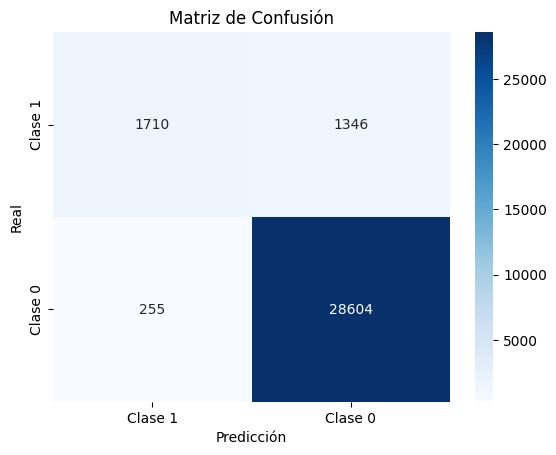

              precision    recall  f1-score   support

           0       0.96      0.99      0.97     28859
           1       0.87      0.56      0.68      3056

    accuracy                           0.95     31915
   macro avg       0.91      0.78      0.83     31915
weighted avg       0.95      0.95      0.94     31915

ROC-AUC: 0.95


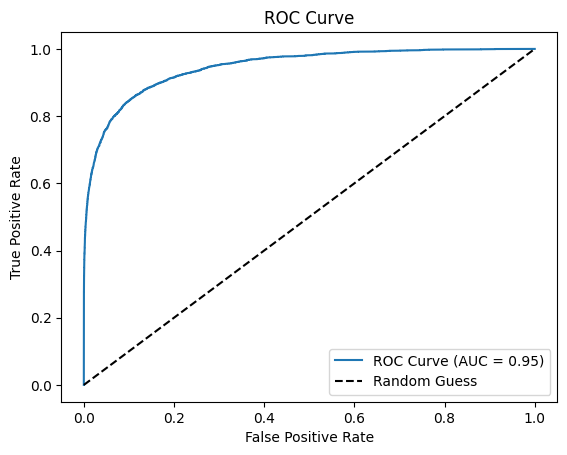

kappa: 0.655304965317433 mcc: 0.6741671880985365


('XGBoost',
 0.9463028764697975,
 np.float64(0.8702290076335878),
 np.float64(0.5595549738219895),
 np.float64(0.6811392152957578),
 np.float64(0.9498355005483315),
 0.655304965317433,
 0.6741671880985365)

In [ ]:
metricas(y_test, xgb_pred, xgb_pred_proba, 'XGBoost')

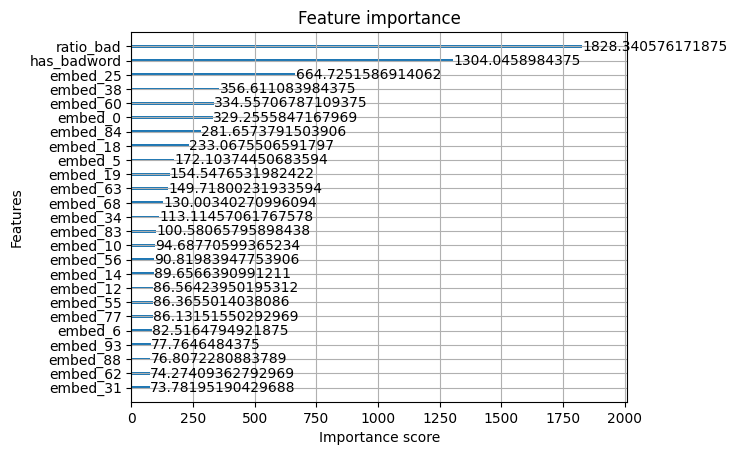

In [ ]:
xgb.plot_importance(XGB_model, importance_type='gain', max_num_features=25)
plt.show()

In [ ]:
## modelo con reduccion de dimensiones PCA

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_embed)
X_pca


array([[-1.12508222,  0.41881939,  0.82300861],
       [ 0.6787394 ,  0.17415769,  1.86779569],
       [-1.56234187, -0.54472013, -0.46342737],
       ...,
       [ 1.42093928,  0.75850898, -0.32305645],
       [-1.46150515,  0.53722722, -0.38268099],
       [-0.46646265, -1.91025559, -1.47743666]], shape=(159571, 3))

In [ ]:
df_pca = pd.DataFrame(
    X_pca,
    columns=[f"pca_{i}" for i in range(X_pca.shape[1])]
)
df_pca

,pca_0,pca_1,pca_2
0,-1.125082,0.418819,0.823009
1,0.678739,0.174158,1.867796
2,-1.562342,-0.544720,-0.463427
3,-0.347829,1.266953,-0.529606
4,-0.000210,-1.277612,0.439186
...,...,...,...
159566,0.201868,0.617275,-2.166207
159567,-1.678906,-1.098062,-0.014401
159568,1.420939,0.758509,-0.323056
159569,-1.461505,0.537227,-0.382681


In [ ]:
X2 = pd.concat([df_pca, df_extra], axis=1)
X2

,pca_0,pca_1,pca_2,comment_length,word_count,has_emoji,has_hash,has_badword,num_badwords,ratio_adj,ratio_noun,ratio_verb,ratio_bad
0,-1.125082,0.418819,0.823009,264,43,0,0,1,1,0.069767,0.348837,0.209302,0.023256
1,0.678739,0.174158,1.867796,112,17,0,0,0,0,0.000000,0.352941,0.176471,0.000000
2,-1.562342,-0.544720,-0.463427,233,42,0,0,0,0,0.047619,0.238095,0.214286,0.000000
3,-0.347829,1.266953,-0.529606,622,113,0,1,0,0,0.061947,0.230088,0.212389,0.000000
4,-0.000210,-1.277612,0.439186,67,13,0,0,0,0,0.000000,0.230769,0.307692,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,0.201868,0.617275,-2.166207,295,47,0,0,0,0,0.106383,0.170213,0.191489,0.000000
159567,-1.678906,-1.098062,-0.014401,99,18,0,0,0,0,0.055556,0.166667,0.222222,0.000000
159568,1.420939,0.758509,-0.323056,81,12,0,0,0,0,0.083333,0.583333,0.083333,0.000000
159569,-1.461505,0.537227,-0.382681,116,25,0,0,0,0,0.040000,0.080000,0.240000,0.000000


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

In [ ]:
XGB_model = XGBClassifier(
    objective='multi:softmax',  # Devuelve directamente la clase predicha
    num_class=3,                # Número de clases en el problema
    max_depth=3,                # Profundidad máxima de los árboles
    learning_rate=0.1,          # Tasa de aprendizaje
    n_estimators=50,            # Número de árboles (rondas de boosting)
    seed=42                     # Semilla para reproducibilidad
)

In [ ]:
XGB_model.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
xgb_pred = XGB_model.predict(X_test)
xgb_pred_proba = XGB_model.predict_proba(X_test)[:, 1]

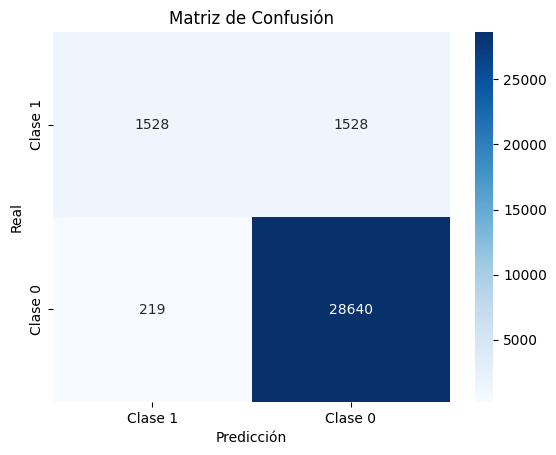

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     28859
           1       0.87      0.50      0.64      3056

    accuracy                           0.95     31915
   macro avg       0.91      0.75      0.80     31915
weighted avg       0.94      0.95      0.94     31915

ROC-AUC: 0.93


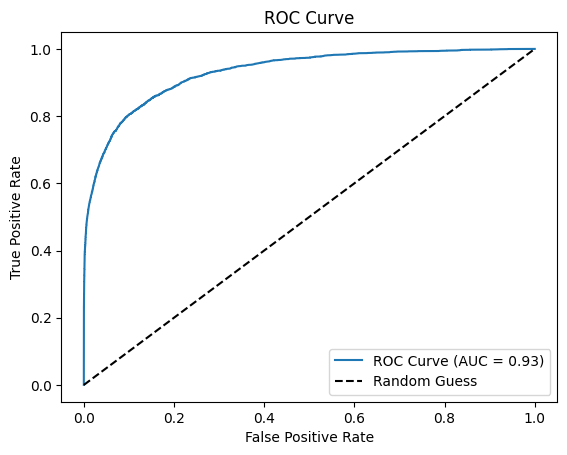

kappa: 0.6090353177767285 mcc: 0.6369798329827655


('XGBoost',
 0.9318788745659751,
 np.float64(0.8746422438465942),
 np.float64(0.5),
 np.float64(0.6362689985425776),
 np.float64(0.9452608491305029),
 0.6090353177767285,
 0.6369798329827655)

In [ ]:
metricas(y_test, xgb_pred, xgb_pred_proba, 'XGBoost')

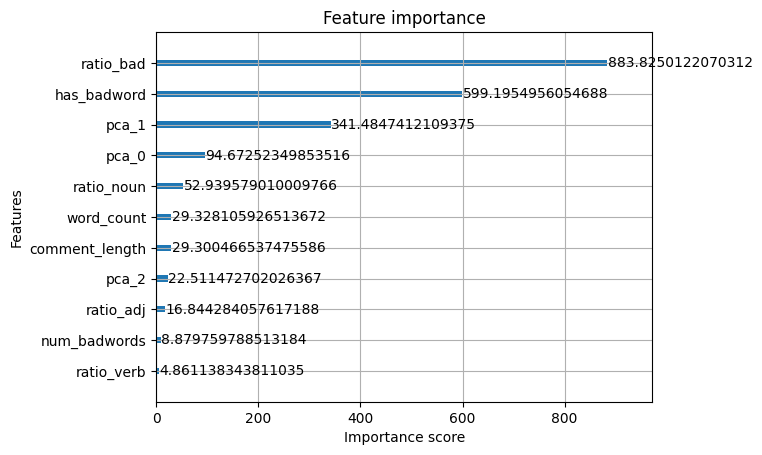

In [ ]:
xgb.plot_importance(XGB_model, importance_type='gain', max_num_features=25)
plt.show()

In [ ]:
## aplicamos bert para obtener los embeddings 

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

def vectorizar(texto):
    tokens = tokenizer(texto, return_tensors="pt", 
                       truncation=True, max_length=512)
    with torch.no_grad():
        output = model(**tokens)
    # Vector del token [CLS] — representa el comentario completo
    return output.last_hidden_state[:, 0, :].numpy()  # (1, 768)

c:\Users\tomas\envs\dl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\tomas\envs\dl\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tomas\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: h

In [ ]:
# tarda muchbo mas de 30 min

In [ ]:
train['comment_vector BERT'] = [vectorizar(texto) for texto in train['comment_text']]
train

In [ ]:
import pandas as pd
import numpy as np

X_embed2 = np.stack(train['comment_vector BERT'].values)

# X_embed es un array de shape (n_samples, embedding_dim)
df_embed2 = pd.DataFrame(
    X_embed2,
    columns=[f"embed_{i}" for i in range(X_embed2.shape[1])]
)
df_embed2

In [ ]:
X3 = pd.concat([df_embed2, df_extra], axis=1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

XGB_model = XGBClassifier(
    objective='multi:softmax',  # Devuelve directamente la clase predicha
    num_class=3,                # Número de clases en el problema
    max_depth=3,                # Profundidad máxima de los árboles
    learning_rate=0.1,          # Tasa de aprendizaje
    n_estimators=50,            # Número de árboles (rondas de boosting)
    seed=42                     # Semilla para reproducibilidad
)

In [ ]:
XGB_model.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
xgb_pred = XGB_model.predict(X_test)
xgb_pred_proba = XGB_model.predict_proba(X_test)[:, 1]

In [ ]:
metricas(y_test, xgb_pred, xgb_pred_proba, 'XGBoost BERT')